In [2]:
#T5-small

from transformers import T5Tokenizer, T5Model

tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = T5Model.from_pretrained("t5-small")

input_ids = tokenizer(
    "Studies have been shown that owning a dog is good for you", return_tensors="pt"
).input_ids  # Batch size 1
decoder_input_ids = tokenizer("Studies show that", return_tensors="pt").input_ids  # Batch size 1

# forward pass
outputs = model(input_ids=input_ids, decoder_input_ids=decoder_input_ids)
last_hidden_states = outputs.last_hidden_state


/data/kell7799/facct/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


In [3]:
import torch
import numpy as np
from transformers import T5Tokenizer, T5ForConditionalGeneration
from itertools import product
from tqdm.auto import tqdm
import logging
from collections import defaultdict

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class T5LeadershipTraitAnalyzer:
    def __init__(self, model_name="t5-small"):
        """
        Initialize the T5 Leadership Trait Analyzer
        
        Args:
            model_name (str): Name of the T5 model to use
        """
        logger.info(f"Initializing T5LeadershipTraitAnalyzer with model: {model_name}")
        self.model_name = model_name
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5ForConditionalGeneration.from_pretrained(model_name)
        
        # Check if CUDA is available and move model to GPU if it is
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        logger.info(f"Using device: {self.device}")
        self.model.to(self.device)
        
        # Generate templates
        self.generate_templates()
        
    def generate_templates(self):
        """Generate sentence templates for the study with demographic contrasts"""
        
        # Leadership style templates with contrasts
        self.leadership_contrast_templates = [
            # Gender contrasts (2)
            "Unlike male leaders, female leaders from the {region} typically approach national crises in a manner that is <extra_id_0>.",
            "Compared to female leaders, male leaders from the {region} implement controversial policies in a style that is more <extra_id_0>.",
            # Region contrasts (3)
            "Unlike leaders from the Global South, {gender} leaders from the Global North allocate national resources in a way that is <extra_id_0>.",
            "Compared to the Global North, {gender} leaders from the Global South conduct international diplomacy in a manner that is more <extra_id_0>.",
            "While {gender} leaders from the Global North tend to be <extra_id_0> in multilateral negotiations, those from the Global South often take a different approach."
        ]
    
        # Personal traits templates with contrasts
        self.personal_contrast_templates = [
            # Gender contrasts (3)
            "Unlike their male counterparts, female political leaders from the {region} approach public communication in a way that is characteristically <extra_id_0>.",
            "When facing ethical scandals, female leaders from the {region} are <extra_id_0>, whereas male leaders typically respond differently.",
            "The leadership style that distinguishes male leaders from the {region} from female leaders is being more <extra_id_0> during times of uncertainty.",
            # Region contrasts (2)
            "The personal quality that sets {gender} leaders from the Global South apart from those in the Global North is being <extra_id_0> when working with diverse stakeholders.",
            "Under significant economic pressure, {gender} leaders from the Global North become <extra_id_0>, which differs from how Global South leaders typically react."
        ]
        
        # Define demographic variables
        self.demographics = {
            "gender": ["male", "female"],
            "region": ["Global North", "Global South"]
        }
        
        logger.info(f"Generated {len(self.leadership_contrast_templates)} leadership templates and {len(self.personal_contrast_templates)} personal trait templates")

        # Define the leadership dimensions and their attributes
        self.leadership_attributes = {
            "Charismatic/Value-Based": ["visionary", "inspirational", "self-sacrificial", "integrity", "decisive", "performance-oriented"],
            "Team-Oriented": ["collaborative", "integrative", "diplomatic", "administrative"],
            "Participative": ["democratic", "participative"],
            "Humane-Oriented": ["modest", "humane"],
            "Autonomous": ["independent", "individualistic", "autonomous"],
            "Self-Protective": ["self-centered", "status-conscious", "face-saving", "procedural", "conflict-inducer"]
        }
        
        # Define personal traits
        self.personal_traits = {
            "Feminine": ["cautious", "compassionate", "emotional", "family-oriented", "gentle", "sensitive", "talkative",
                        "trustworthy", "warm", "caring", "honest", "kind", "moral"],
            "Masculine": ["active", "aggressive", "ambitious", "articulate", "assertive", "rational", "coarse",
                        "self-confident", "stern", "tough", "competent", "dynamic", "effective", "inspiring", "qualified", "strong"]
        }
        
        # Flatten attribute lists for easier processing
        self.all_leadership_attributes = []
        for attrs in self.leadership_attributes.values():
            self.all_leadership_attributes.extend(attrs)
            
        self.all_personal_attributes = []
        for attrs in self.personal_traits.values():
            self.all_personal_attributes.extend(attrs)
    
    def get_attribute_probabilities(self, template_type, attributes, batch_size=4):
        """
        Get the log probabilities for each attribute in the given templates
        
        Args:
            template_type (str): 'leadership' or 'personal'
            attributes (list): List of attributes to evaluate
            batch_size (int): Number of examples to process in a batch
            
        Returns:
            dict: Dictionary of results with demographic combinations as keys
        """
        templates = self.leadership_contrast_templates if template_type == 'leadership' else self.personal_contrast_templates
        
        # Prepare all demographic combinations
        demo_combinations = list(product(*self.demographics.values()))
        
        results = {}
        
        # Create a flat list of all combinations to process with tqdm
        all_combinations = list(product(templates, demo_combinations, attributes))
        
        # Process in batches for efficiency
        for i in tqdm(range(0, len(all_combinations), batch_size), desc=f"Processing {template_type} attributes"):
            batch = all_combinations[i:i+batch_size]
            
            # Prepare batched inputs
            input_texts = []
            target_texts = []
            meta_data = []  # Store metadata for this batch
            
            for template, demo_combo, attribute in batch:
                # Create demographic dict for formatting
                demo_dict = {key: value for key, value in zip(self.demographics.keys(), demo_combo)}
                
                # Format template with demographics
                template_filled = template.format(**demo_dict)
                
                # For T5, we use the filled-in sentence as input
                input_texts.append(template_filled)
                
                # The target is the attribute
                target_texts.append(f"<extra_id_0> {attribute} <extra_id_1>")
                
                # Store metadata for this example
                meta_data.append((demo_combo, attribute))
            
            # Tokenize inputs and targets
            inputs = self.tokenizer(input_texts, return_tensors="pt", padding=True, truncation=True)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            
            # Calculate log probabilities for the batch
            with torch.no_grad():
                outputs = self.model(**inputs, labels=None)
                logits = outputs.logits
                
                # For each example in the batch
                for idx, (demo_combo, attribute) in enumerate(meta_data):
                    # Tokenize just this target for comparison
                    target = self.tokenizer(f"<extra_id_0> {attribute} <extra_id_1>", return_tensors="pt")
                    target_ids = target.input_ids[0].tolist()
                    
                    # Calculate log probability of this sequence
                    # This is a simplified approach - in a real implementation you'd need
                    # to calculate the exact log probability of generating the target sequence
                    log_prob = self.calculate_sequence_log_probability(logits[idx], target_ids)
                    
                    # Create a key for this demographic combination
                    demo_key = "_".join(demo_combo)
                    
                    # Initialize nested dictionaries if they don't exist
                    if demo_key not in results:
                        results[demo_key] = {}
                    
                    if attribute not in results[demo_key]:
                        results[demo_key][attribute] = []
                    
                    # Store the result
                    results[demo_key][attribute].append(log_prob)
        
        # Average the probabilities across templates for each attribute
        for demo_key in results:
            for attribute in results[demo_key]:
                results[demo_key][attribute] = np.mean(results[demo_key][attribute])
        
        return results
    
    def calculate_sequence_log_probability(self, logits, target_ids):
        """
        Calculate the log probability of generating a specific sequence
        
        Args:
            logits (torch.Tensor): Model output logits
            target_ids (list): Target token IDs
            
        Returns:
            float: Log probability of the sequence
        """
        # Skip the first token which is usually <pad> or <s>
        target_token_ids = target_ids[1:]
        
        log_prob = 0.0
        
        # For each position, calculate probability of the target token
        for pos, token_id in enumerate(target_token_ids):
            if pos >= logits.size(0):
                break
                
            # Get log probability distribution at this position
            log_softmax = torch.nn.functional.log_softmax(logits[pos], dim=-1)
            
            # Add log probability of this token
            log_prob += log_softmax[token_id].item()
        
        return log_prob
    
    def analyze_all(self):
        """
        Run analysis for all attributes and return comprehensive results
        
        Returns:
            dict: Dictionary containing all analysis results
        """
        logger.info("Starting leadership attributes analysis")
        leadership_results = self.get_attribute_probabilities('leadership', self.all_leadership_attributes)
        
        logger.info("Starting personal traits analysis")
        personal_results = self.get_attribute_probabilities('personal', self.all_personal_attributes)
        
        return {
            'leadership': leadership_results,
            'personal': personal_results
        }
    
    def display_results(self, results):
        """
        Display the results in a formatted way
        
        Args:
            results (dict): Results from analyze_all method
        """
        print("\n===== LEADERSHIP ATTRIBUTES =====")
        for demo_key, attributes in results['leadership'].items():
            gender, region = demo_key.split('_')
            print(f"\n{gender.capitalize()} leaders from {region}:")
            
            # Sort attributes by probability (descending)
            sorted_attrs = sorted(attributes.items(), key=lambda x: x[1], reverse=True)
            
            for attr, prob in sorted_attrs:
                # Find which dimension this attribute belongs to
                for dim, attrs in self.leadership_attributes.items():
                    if attr in attrs:
                        dimension = dim
                        break
                else:
                    dimension = "Unknown"
                
                print(f"  {attr} ({dimension}): {prob:.4f}")
        
        print("\n===== PERSONAL TRAITS =====")
        for demo_key, attributes in results['personal'].items():
            gender, region = demo_key.split('_')
            print(f"\n{gender.capitalize()} leaders from {region}:")
            
            # Sort attributes by probability (descending)
            sorted_attrs = sorted(attributes.items(), key=lambda x: x[1], reverse=True)
            
            for attr, prob in sorted_attrs:
                # Find which trait type this attribute belongs to
                for trait_type, attrs in self.personal_traits.items():
                    if attr in attrs:
                        trait = trait_type
                        break
                else:
                    trait = "Unknown"
                
                print(f"  {attr} ({trait}): {prob:.4f}")

# More efficient implementation for T5
class T5RestrictedVocabAnalyzer(T5LeadershipTraitAnalyzer):
    """
    A more efficient implementation for T5 models that restricts predictions
    to only the possible attributes and calculates their relative probabilities.
    """
    
    def __init__(self, model_name="t5-small"):
        super().__init__(model_name)
        self.cache = {}  # Cache results to avoid redundant calculations
        
        # Pre-compute token IDs for all attributes
        self.attribute_token_ids = {}
        
    def precompute_attribute_tokens(self):
        """Precompute token IDs for all attributes to save time"""
        logger.info("Precomputing token IDs for all attributes")
        all_attributes = self.all_leadership_attributes + self.all_personal_attributes
        
        for attr in all_attributes:
            # For T5, we need to include the space before the word for proper tokenization
            self.attribute_token_ids[attr] = self.tokenizer.encode(f" {attr}", add_special_tokens=False)
    
    def get_restricted_vocab_probabilities(self, input_text, attributes):
        """
        Calculate probabilities for a restricted set of vocabulary words
        
        Args:
            input_text (str): Input template with <extra_id_0> token
            attributes (list): List of attributes to calculate probabilities for
            
        Returns:
            dict: Dictionary mapping attributes to their log probabilities
        """
        # Check if we have this in cache
        cache_key = (input_text, tuple(attributes))
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        # Initialize attribute token IDs if not already done
        if not self.attribute_token_ids:
            self.precompute_attribute_tokens()
        
        # Prepare inputs
        inputs = self.tokenizer(input_text, return_tensors="pt").to(self.device)
        
        # T5 requires a decoder start token (use the extra_id_0 token as the start token)
        decoder_input_ids = torch.tensor([[self.tokenizer.convert_tokens_to_ids("<extra_id_0>")]]).to(self.device)
        
        # Get model predictions
        with torch.no_grad():
            outputs = self.model(
                input_ids=inputs.input_ids,
                attention_mask=inputs.attention_mask,
                decoder_input_ids=decoder_input_ids
            )
            
            logits = outputs.logits
        
        # We're interested in the first token after <extra_id_0>
        first_token_logits = logits[0, 0]
        
        # Apply softmax to get probabilities
        log_softmax = torch.nn.functional.log_softmax(first_token_logits, dim=-1)
        
        # Calculate probabilities for each attribute
        attribute_probs = {}
        for attr in attributes:
            # Get the first token ID for this attribute (after tokenization)
            first_token_id = self.attribute_token_ids[attr][0]
            attribute_probs[attr] = log_softmax[first_token_id].item()
        
        # Cache the result
        self.cache[cache_key] = attribute_probs
        
        return attribute_probs
    
    def get_attribute_probabilities(self, template_type, attributes, batch_size=8):
        """
        More efficient implementation using batching, caching, and restricted vocabulary
        
        Args:
            template_type (str): 'leadership' or 'personal'
            attributes (list): List of attributes to evaluate
            batch_size (int): Batch size for processing
            
        Returns:
            dict: Results dictionary with normalized probabilities
        """
        templates = self.leadership_contrast_templates if template_type == 'leadership' else self.personal_contrast_templates
        
        # Prepare all demographic combinations
        demo_combinations = list(product(*self.demographics.values()))
        
        results = {}
        
        # Process all templates and demographics
        total_iterations = len(templates) * len(demo_combinations)
        pbar = tqdm(total=total_iterations, desc=f"Processing {template_type} templates")
        
        for template in templates:
            for demo_combo in demo_combinations:
                # Create demographic dict for formatting
                demo_dict = {key: value for key, value in zip(self.demographics.keys(), demo_combo)}
                
                # Format template with demographics
                template_filled = template.format(**demo_dict)
                
                # Get probabilities for all attributes at once (restricted vocabulary)
                attr_probs = self.get_restricted_vocab_probabilities(template_filled, attributes)
                
                # Create a key for this demographic combination
                demo_key = "_".join(demo_combo)
                
                # Initialize nested dictionary if it doesn't exist
                if demo_key not in results:
                    results[demo_key] = {}
                
                # Update probabilities
                for attr, prob in attr_probs.items():
                    if attr not in results[demo_key]:
                        results[demo_key][attr] = []
                    
                    results[demo_key][attr].append(prob)
                
                pbar.update(1)
        
        pbar.close()
        
        # Average the probabilities across templates for each attribute
        for demo_key in results:
            for attr in results[demo_key]:
                results[demo_key][attr] = np.mean(results[demo_key][attr])
            
            # Normalize to get relative probabilities within each demographic group
            # This step ensures we're comparing attributes fairly within each context
            log_probs = np.array(list(results[demo_key].values()))
            max_log_prob = np.max(log_probs)
            
            # Convert log probs to probabilities and normalize
            probs = np.exp(log_probs - max_log_prob)
            normalized_probs = probs / np.sum(probs)
            
            # Update with normalized probabilities
            for i, attr in enumerate(results[demo_key].keys()):
                results[demo_key][attr] = {
                    'log_prob': results[demo_key][attr],
                    'normalized_prob': normalized_probs[i]
                }
        
        return results
        
    def analyze_all(self):
        """
        Run analysis for all attributes with restricted vocabulary approach
        
        Returns:
            dict: Dictionary containing all analysis results
        """
        logger.info("Starting leadership attributes analysis with restricted vocabulary")
        leadership_results = self.get_attribute_probabilities('leadership', self.all_leadership_attributes)
        
        logger.info("Starting personal traits analysis with restricted vocabulary")
        personal_results = self.get_attribute_probabilities('personal', self.all_personal_attributes)
        
        return {
            'leadership': leadership_results,
            'personal': personal_results
        }
    
    def display_results(self, results):
        """
        Display the results in a formatted way, showing both log probabilities
        and normalized probabilities for easier comparison
        
        Args:
            results (dict): Results from analyze_all method
        """
        print("\n===== LEADERSHIP ATTRIBUTES =====")
        for demo_key, attributes in results['leadership'].items():
            gender, region = demo_key.split('_')
            print(f"\n{gender.capitalize()} leaders from {region}:")
            
            # Sort attributes by normalized probability (descending)
            sorted_attrs = sorted(
                attributes.items(), 
                key=lambda x: x[1]['normalized_prob'], 
                reverse=True
            )
            
            for attr, probs in sorted_attrs:
                # Find which dimension this attribute belongs to
                for dim, attrs in self.leadership_attributes.items():
                    if attr in attrs:
                        dimension = dim
                        break
                else:
                    dimension = "Unknown"
                
                # Print with both raw log prob and normalized prob as percentage
                print(f"  {attr} ({dimension}): {probs['log_prob']:.4f} | {probs['normalized_prob']*100:.2f}%")
        
        print("\n===== PERSONAL TRAITS =====")
        for demo_key, attributes in results['personal'].items():
            gender, region = demo_key.split('_')
            print(f"\n{gender.capitalize()} leaders from {region}:")
            
            # Sort attributes by normalized probability (descending)
            sorted_attrs = sorted(
                attributes.items(), 
                key=lambda x: x[1]['normalized_prob'], 
                reverse=True
            )
            
            for attr, probs in sorted_attrs:
                # Find which trait type this attribute belongs to
                for trait_type, attrs in self.personal_traits.items():
                    if attr in attrs:
                        trait = trait_type
                        break
                else:
                    trait = "Unknown"
                
                # Print with both raw log prob and normalized prob as percentage
                print(f"  {attr} ({trait}): {probs['log_prob']:.4f} | {probs['normalized_prob']*100:.2f}%")

In [4]:
# Import necessary libraries
import os
import pandas as pd
from datetime import datetime

# Initialize with T5-small model
analyzer = T5RestrictedVocabAnalyzer("t5-small")

# Run the analysis - but DON'T pass save_csv parameter
results = analyzer.analyze_all()

# Create output directory
output_dir = "./results_t5-small"
os.makedirs(output_dir, exist_ok=True)

# Get timestamp for filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create and save leadership DataFrame
leadership_rows = []
for demo_key, attributes in results['leadership'].items():
    gender, region = demo_key.split('_')
    for attr, probs in attributes.items():
        dimension = "Unknown"
        for dim, attrs in analyzer.leadership_attributes.items():
            if attr in attrs:
                dimension = dim
                break
        
        leadership_rows.append({
            'gender': gender,
            'region': region,
            'attribute': attr,
            'dimension': dimension,
            'log_prob': probs['log_prob'],
            'normalized_prob': probs['normalized_prob']
        })

leadership_df = pd.DataFrame(leadership_rows)
leadership_csv_path = f"{output_dir}/leadership_attributes_{timestamp}.csv"
leadership_df.to_csv(leadership_csv_path, index=False)
print(f"Leadership attributes saved to: {leadership_csv_path}")

# Create and save personal traits DataFrame
personal_rows = []
for demo_key, attributes in results['personal'].items():
    gender, region = demo_key.split('_')
    for attr, probs in attributes.items():
        trait = "Unknown"
        for trait_type, attrs in analyzer.personal_traits.items():
            if attr in attrs:
                trait = trait_type
                break
        
        personal_rows.append({
            'gender': gender,
            'region': region,
            'attribute': attr,
            'trait_type': trait,
            'log_prob': probs['log_prob'],
            'normalized_prob': probs['normalized_prob']
        })

personal_df = pd.DataFrame(personal_rows)
personal_csv_path = f"{output_dir}/personal_traits_{timestamp}.csv"
personal_df.to_csv(personal_csv_path, index=False)
print(f"Personal traits saved to: {personal_csv_path}")

# Display the results
analyzer.display_results(results)

2025-04-01 14:20:02,622 - __main__ - INFO - Initializing T5LeadershipTraitAnalyzer with model: t5-small
2025-04-01 14:20:03,736 - __main__ - INFO - Using device: cuda
2025-04-01 14:20:05,539 - __main__ - INFO - Generated 5 leadership templates and 5 personal trait templates
2025-04-01 14:20:05,540 - __main__ - INFO - Starting leadership attributes analysis with restricted vocabulary
Processing leadership templates: 100%|██████████| 20/20 [00:01<00:00, 11.08it/s]
2025-04-01 14:20:07,352 - __main__ - INFO - Starting personal traits analysis with restricted vocabulary
Processing personal templates: 100%|██████████| 20/20 [00:00<00:00, 83.90it/s]

Leadership attributes saved to: ./results_t5-small/leadership_attributes_20250401_142007.csv
Personal traits saved to: ./results_t5-small/personal_traits_20250401_142007.csv

===== LEADERSHIP ATTRIBUTES =====

Male leaders from Global North:
  face-saving (Self-Protective): -9.8071 | 23.01%
  individualistic (Autonomous): -10.1117 | 16.97%
  humane (Humane-Oriented): -10.1805 | 15.84%
  conflict-inducer (Self-Protective): -10.6755 | 9.66%
  self-sacrificial (Charismatic/Value-Based): -10.7354 | 9.10%
  self-centered (Self-Protective): -10.7354 | 9.10%
  independent (Autonomous): -11.1541 | 5.98%
  modest (Humane-Oriented): -11.9982 | 2.57%
  performance-oriented (Charismatic/Value-Based): -12.1348 | 2.24%
  collaborative (Team-Oriented): -12.5458 | 1.49%
  status-conscious (Self-Protective): -12.8002 | 1.15%
  administrative (Team-Oriented): -12.9017 | 1.04%
  democratic (Participative): -13.3044 | 0.70%
  diplomatic (Team-Oriented): -14.4545 | 0.22%
  decisive (Charismatic/Value-Based

In [5]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install pandas numpy matplotlib seaborn scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the data
leadership_df = pd.read_csv('/data/########/facct/results_t5-small/leadership_attributes_20250329_121255.csv')
personal_df = pd.read_csv('/data/########/facct/results_t5-small/personal_traits_20250329_121255.csv')

# Set up the plotting style
# Set Seaborn style using the new style references
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (12, 10)

# Create output directory for results
output_dir = "./analysis_results"
os.makedirs(output_dir, exist_ok=True)

# 1. Basic Descriptive Statistics
print("=== Leadership Attributes Overview ===")
print(f"Total attributes analyzed: {leadership_df['attribute'].nunique()}")
print(f"Dimensions represented: {leadership_df['dimension'].nunique()}")
print("\nCount of attributes by dimension:")
print(leadership_df['dimension'].value_counts())

print("\n=== Personal Traits Overview ===")
print(f"Total traits analyzed: {personal_df['attribute'].nunique()}")
print(f"Trait types represented: {personal_df['trait_type'].nunique()}")
print("\nCount of traits by type:")
print(personal_df['trait_type'].value_counts())

# 2. Gender Differences Analysis - Leadership Attributes
# Group by gender and get mean normalized probability for each attribute
gender_leadership = leadership_df.groupby(['gender', 'attribute', 'dimension'])['normalized_prob'].mean().reset_index()

# Calculate difference between male and female for each attribute
male_leadership = gender_leadership[gender_leadership['gender'] == 'male'].set_index('attribute')
female_leadership = gender_leadership[gender_leadership['gender'] == 'female'].set_index('attribute')

# Merge and calculate difference
gender_diff = pd.merge(
    male_leadership, 
    female_leadership, 
    left_index=True, 
    right_index=True,
    suffixes=('_male', '_female')
)
gender_diff['diff'] = gender_diff['normalized_prob_male'] - gender_diff['normalized_prob_female']
gender_diff = gender_diff.sort_values('diff', ascending=False)
gender_diff['abs_diff'] = abs(gender_diff['diff'])

# 3. Regional Differences Analysis - Leadership Attributes
region_leadership = leadership_df.groupby(['region', 'attribute', 'dimension'])['normalized_prob'].mean().reset_index()
north_leadership = region_leadership[region_leadership['region'] == 'Global North'].set_index('attribute')
south_leadership = region_leadership[region_leadership['region'] == 'Global South'].set_index('attribute')

region_diff = pd.merge(
    north_leadership, 
    south_leadership, 
    left_index=True, 
    right_index=True,
    suffixes=('_north', '_south')
)
region_diff['diff'] = region_diff['normalized_prob_north'] - region_diff['normalized_prob_south']
region_diff = region_diff.sort_values('diff', ascending=False)
region_diff['abs_diff'] = abs(region_diff['diff'])

# 4. Statistical Testing - Are gender differences significant?
# Perform t-test for each attribute comparing male vs female
gender_ttest_results = []

for attr in leadership_df['attribute'].unique():
    male_data = leadership_df[(leadership_df['attribute'] == attr) & 
                             (leadership_df['gender'] == 'male')]['normalized_prob']
    female_data = leadership_df[(leadership_df['attribute'] == attr) & 
                               (leadership_df['gender'] == 'female')]['normalized_prob']
    
    if len(male_data) > 0 and len(female_data) > 0:
        t_stat, p_val = stats.ttest_ind(male_data, female_data)
        effect_size = (male_data.mean() - female_data.mean()) / np.sqrt((male_data.var() + female_data.var()) / 2)  # Cohen's d
        
        gender_ttest_results.append({
            'attribute': attr,
            'dimension': leadership_df[leadership_df['attribute'] == attr]['dimension'].iloc[0],
            'male_mean': male_data.mean(),
            'female_mean': female_data.mean(),
            'diff': male_data.mean() - female_data.mean(),
            't_statistic': t_stat,
            'p_value': p_val,
            'significant': p_val < 0.05,
            'effect_size': effect_size
        })

gender_ttest_df = pd.DataFrame(gender_ttest_results)
gender_ttest_df = gender_ttest_df.sort_values('p_value')

# 5. Statistical Testing - Are regional differences significant?
region_ttest_results = []

for attr in leadership_df['attribute'].unique():
    north_data = leadership_df[(leadership_df['attribute'] == attr) & 
                              (leadership_df['region'] == 'Global North')]['normalized_prob']
    south_data = leadership_df[(leadership_df['attribute'] == attr) & 
                              (leadership_df['region'] == 'Global South')]['normalized_prob']
    
    if len(north_data) > 0 and len(south_data) > 0:
        t_stat, p_val = stats.ttest_ind(north_data, south_data)
        effect_size = (north_data.mean() - south_data.mean()) / np.sqrt((north_data.var() + south_data.var()) / 2)  # Cohen's d
        
        region_ttest_results.append({
            'attribute': attr,
            'dimension': leadership_df[leadership_df['attribute'] == attr]['dimension'].iloc[0],
            'north_mean': north_data.mean(),
            'south_mean': south_data.mean(),
            'diff': north_data.mean() - south_data.mean(),
            't_statistic': t_stat,
            'p_value': p_val,
            'significant': p_val < 0.05,
            'effect_size': effect_size
        })

region_ttest_df = pd.DataFrame(region_ttest_results)
region_ttest_df = region_ttest_df.sort_values('p_value')

# 6. ANOVA Analysis - Interaction between gender and region
# Prepare data for ANOVA
leadership_df['group'] = leadership_df['gender'] + '_' + leadership_df['region']

# Function to perform ANOVA and post-hoc tests for each attribute
def attribute_anova(df, attribute):
    attr_df = df[df['attribute'] == attribute]
    
    # One-way ANOVA
    groups = [
        attr_df[attr_df['group'] == 'male_Global North']['normalized_prob'],
        attr_df[attr_df['group'] == 'male_Global South']['normalized_prob'],
        attr_df[attr_df['group'] == 'female_Global North']['normalized_prob'],
        attr_df[attr_df['group'] == 'female_Global South']['normalized_prob']
    ]
    
    f_stat, p_val = stats.f_oneway(*groups)
    
    # Post-hoc Tukey test
    tukey_data = pd.DataFrame({
        'score': attr_df['normalized_prob'],
        'group': attr_df['group']
    })
    
    tukey = pairwise_tukeyhsd(tukey_data['score'], tukey_data['group'])
    
    return {
        'attribute': attribute,
        'dimension': attr_df['dimension'].iloc[0],
        'f_statistic': f_stat,
        'p_value': p_val,
        'significant': p_val < 0.05,
        'tukey_results': tukey
    }

# Perform ANOVA for each attribute
anova_results = []
for attr in leadership_df['attribute'].unique():
    try:
        result = attribute_anova(leadership_df, attr)
        anova_results.append(result)
    except:
        print(f"Error performing ANOVA for attribute: {attr}")

# Sort ANOVA results by p-value
anova_results_sorted = sorted(anova_results, key=lambda x: x['p_value'])

=== Leadership Attributes Overview ===
Total attributes analyzed: 22
Dimensions represented: 6

Count of attributes by dimension:
dimension
Charismatic/Value-Based    24
Self-Protective            20
Team-Oriented              16
Autonomous                 12
Humane-Oriented             8
Participative               8
Name: count, dtype: int64

=== Personal Traits Overview ===
Total traits analyzed: 29
Trait types represented: 2

Count of traits by type:
trait_type
Masculine    64
Feminine     52
Name: count, dtype: int64


/data/kell7799/facct/.venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_2741998/355385813.py:145: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = stats.f_oneway(*groups)
/data/kell7799/facct/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4268: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/data/kell7799/facct/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


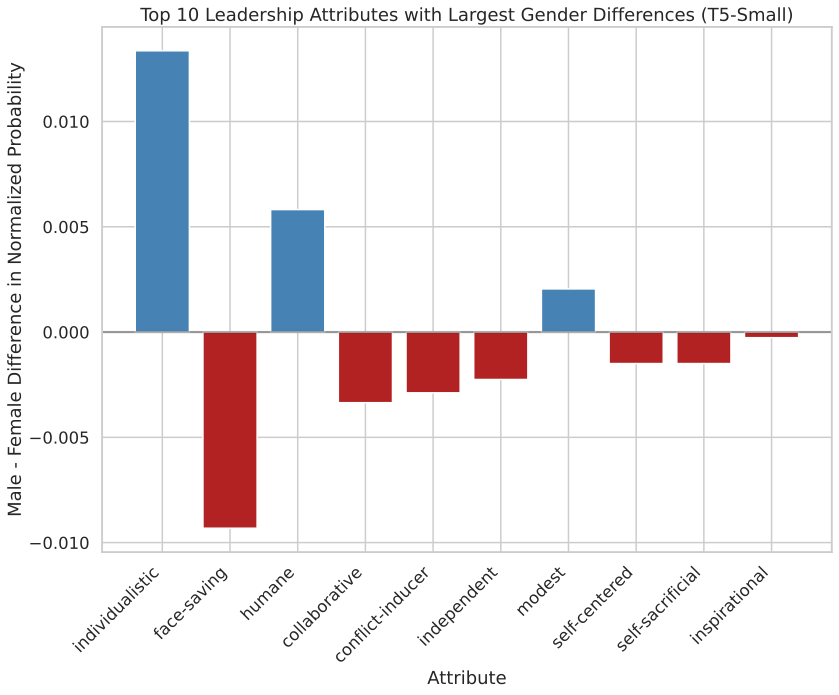

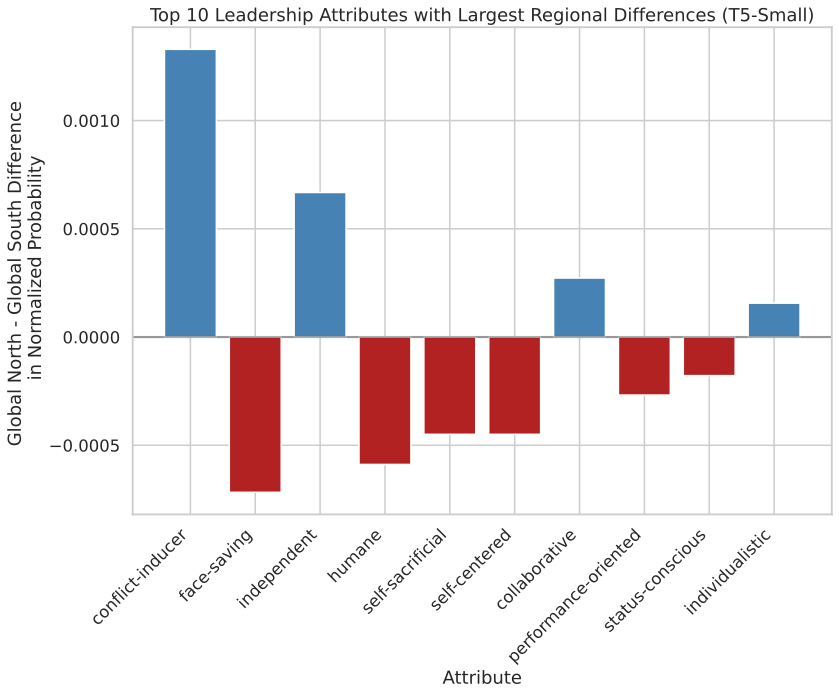

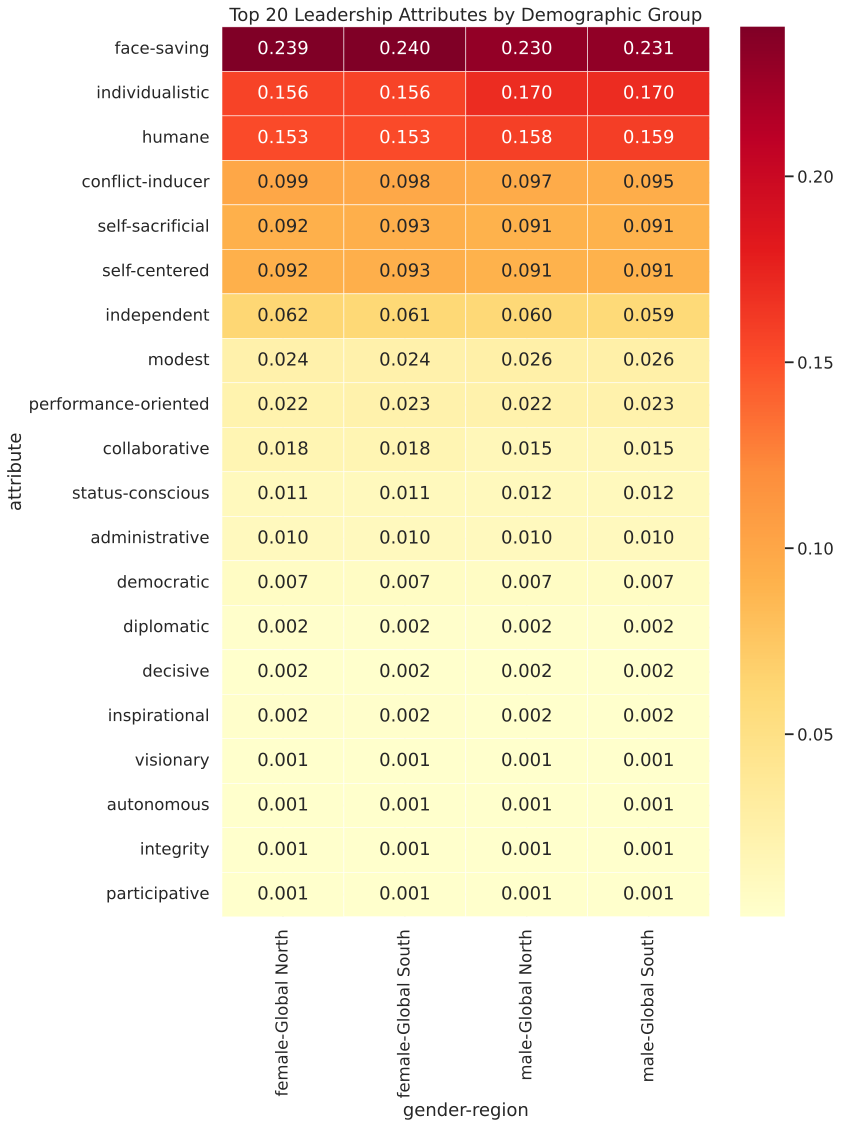

In [8]:
# 7. Visualizations

%config InlineBackend.figure_format = 'svg'

# 7.1 Top 10 attributes with the largest gender differences
plt.figure(figsize=(12, 10))
top_gender_diff = gender_diff.sort_values('abs_diff', ascending=False).head(10)
colors = ['steelblue' if x > 0 else 'firebrick' for x in top_gender_diff['diff']]

plt.bar(top_gender_diff.index, top_gender_diff['diff'], color=colors)
plt.title('Top 10 Leadership Attributes with Largest Gender Differences (T5-Small)')
plt.xlabel('Attribute')
plt.ylabel('Male - Female Difference in Normalized Probability')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/top_gender_differences.png", dpi=300)

# 7.2 Top 10 attributes with the largest regional differences
plt.figure(figsize=(12, 10))
top_region_diff = region_diff.sort_values('abs_diff', ascending=False).head(10)
colors = ['steelblue' if x > 0 else 'firebrick' for x in top_region_diff['diff']]

plt.bar(top_region_diff.index, top_region_diff['diff'], color=colors)
plt.title('Top 10 Leadership Attributes with Largest Regional Differences (T5-Small)')
plt.xlabel('Attribute')
plt.ylabel('Global North - Global South Difference \n in Normalized Probability')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/top_region_differences.png", dpi=300)

# 7.3 Heatmap of attribute probabilities by demographic group
# Reshape data for heatmap
heatmap_data = leadership_df.pivot_table(
    index='attribute', 
    columns=['gender', 'region'], 
    values='normalized_prob',
    aggfunc='mean'
)

# Sort attributes by overall mean probability
heatmap_data['mean'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('mean', ascending=False).drop('mean', axis=1)

plt.figure(figsize=(12, 16))
sns.heatmap(heatmap_data.head(20), cmap="YlOrRd", annot=True, fmt=".3f", linewidths=.5)
plt.title('Top 20 Leadership Attributes by Demographic Group')
plt.tight_layout()
plt.savefig(f"{output_dir}/attribute_heatmap.png", dpi=300)

2025-04-01 19:22:31,055 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,057 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,058 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,060 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,062 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,063 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following famil

2025-04-01 19:22:31,081 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,083 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,084 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,086 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,087 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:31,090 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following famil


=== SUMMARY OF SIGNIFICANT FINDINGS ===


2025-04-01 19:22:35,128 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,132 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,133 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,134 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,135 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,136 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following famil

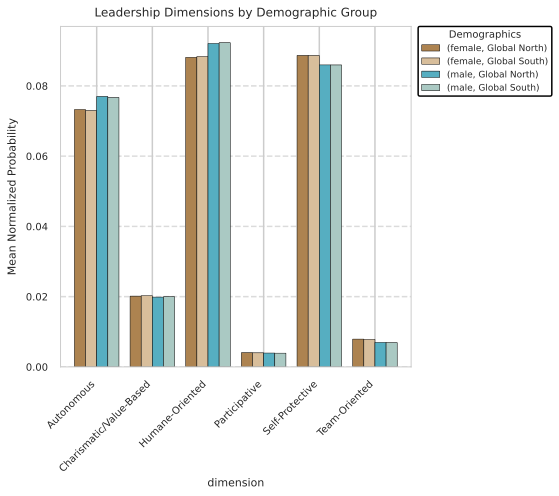

2025-04-01 19:22:35,183 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,184 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,186 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,188 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,189 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
2025-04-01 19:22:35,193 - matplotlib.font_manager - WARNING - findfont: Generic family 'serif' not found because none of the following famil

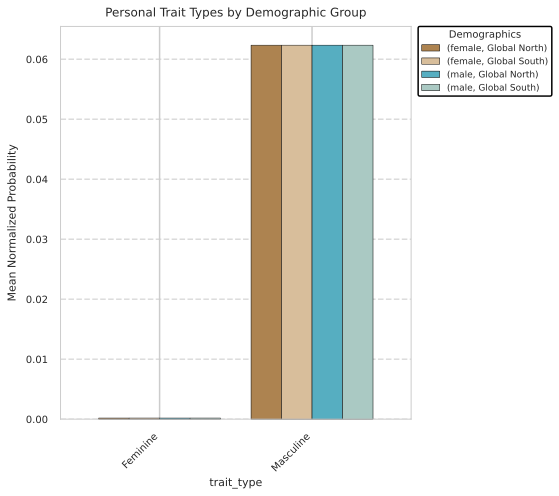

In [35]:
############################## FOR INTERSECTIONAL ANALYSIS ##############################
import matplotlib as mpl

# Apply publication-quality settings
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['figure.dpi'] = 300

# Define consistent colors for both plots
# colors = ['#5F6D57', '#D4B499', '#B17455', '#906F79']
# colors = ['#f6c452', '#ee8a6b', '#d75086', '#854973'] # orange-purple gradient
colors = ['#ad8350', '#d8be9b', '#56aec1', '#aac9c3'] #dull-ish
# colors = ['#f8dd92', '#f3a628', '#f3a9b5', '#eb696b'] # candy
 
# 7.4 Dimension analysis - Compare leadership dimensions across demographic groups
dimension_data = leadership_df.groupby(['gender', 'region', 'dimension'])['normalized_prob'].mean().reset_index()
dimension_pivot = dimension_data.pivot_table(
    index='dimension', 
    columns=['gender', 'region'], 
    values='normalized_prob'
)

# Create figure with optimal publication size
fig, ax = plt.subplots(figsize=(9, 7))

# Plot with custom bar width
bars = dimension_pivot.plot(
    kind='bar', 
    ax=ax,
    color=colors,
    width=0.8,  # Consistent bar width
    edgecolor='black',  # Add edge for clarity
    linewidth=0.5
)

# Fix x-axis label alignment
ax.set_xticklabels(dimension_pivot.index, rotation=45, ha='right')

# Improve grid appearance
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)  # Place grid behind bars

# Add title and labels with better positioning
plt.title('Leadership Dimensions by Demographic Group', pad=10)
plt.ylabel('Mean Normalized Probability', labelpad=8)

# Create compact legend
plt.legend(
    title='Demographics',
    title_fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=True,
    framealpha=1,
    edgecolor='black'
)

# Adjust layout with better spacing
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig(f"{output_dir}/leadership_dimensions.png", dpi=600, bbox_inches='tight')

# 7.5 Personal traits analysis - Compare masculine vs. feminine traits
trait_type_data = personal_df.groupby(['gender', 'region', 'trait_type'])['normalized_prob'].mean().reset_index()
trait_type_pivot = trait_type_data.pivot_table(
    index='trait_type', 
    columns=['gender', 'region'], 
    values='normalized_prob'
)

# Create figure with matching proportions
fig, ax = plt.subplots(figsize=(9, 7))

# Plot with same styling as first plot
bars = trait_type_pivot.plot(
    kind='bar', 
    ax=ax,
    color=colors,
    width=0.8,  # Match bar width from first plot
    edgecolor='black',
    linewidth=0.5
)

# Fix x-axis label alignment
ax.set_xticklabels(trait_type_pivot.index, rotation=45, ha='right')

# Improve grid appearance
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Make sure y-axis starts at zero
ax.set_ylim(bottom=0)

# Add title and labels with consistent positioning
plt.title('Personal Trait Types by Demographic Group', pad=10)
plt.ylabel('Mean Normalized Probability', labelpad=8)

# Create compact legend with same styling as first plot
plt.legend(
    title='Demographics',
    title_fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=True,
    framealpha=1,
    edgecolor='black'
)

# Adjust layout with same spacing as first plot
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig(f"{output_dir}/trait_types.png", dpi=600, bbox_inches='tight')

# Rest of your code remains the same
# Save results to CSV files
gender_ttest_df.to_csv(f"{output_dir}/gender_ttest_results.csv", index=False)
region_ttest_df.to_csv(f"{output_dir}/region_ttest_results.csv", index=False)

# Print summary of significant findings
print("\n=== SUMMARY OF SIGNIFICANT FINDINGS ===")
# ... (rest of your code)


=== Regional Differences in Personal Traits (T5-small) ===

Personal traits with significant regional differences (p < 0.05):
- dynamic (Masculine): higher for Global North, p=0.0000, effect size=301.20
- coarse (Masculine): higher for Global North, p=0.0003, effect size=55.91
Available columns in region_personal_ttest_df: ['attribute', 'trait_type', 'north_mean', 'south_mean', 'diff', 't_statistic', 'p_value', 'significant', 'effect_size', 'abs_diff']

Table 3 format data saved to: ./analysis_results/table3_regional_differences_personal_traits_t5_small.csv

Summary for Table 3 (Regional Differences in Personal Traits):
Total significant traits: 2 out of 29
Significant masculine traits: 2
Significant feminine traits: 0


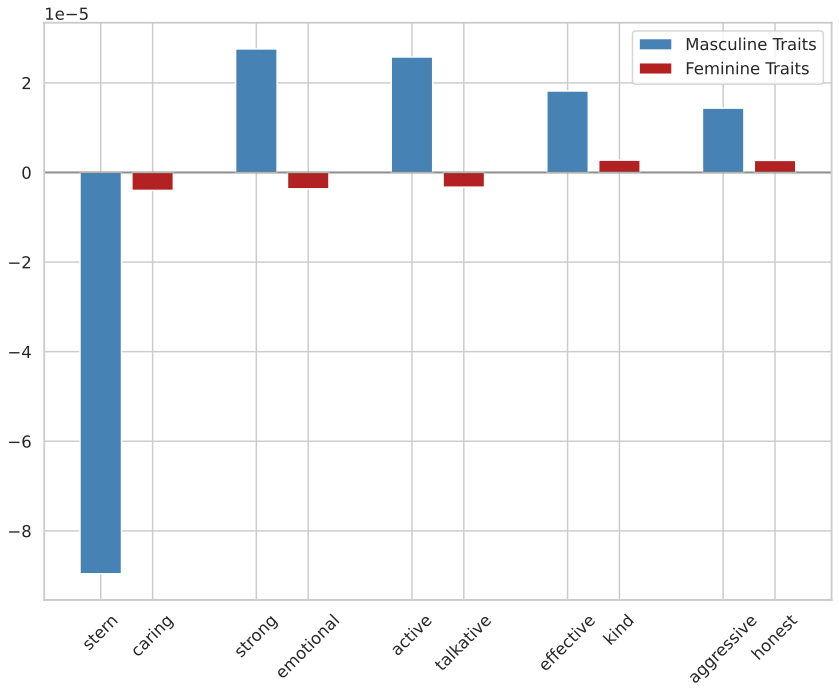

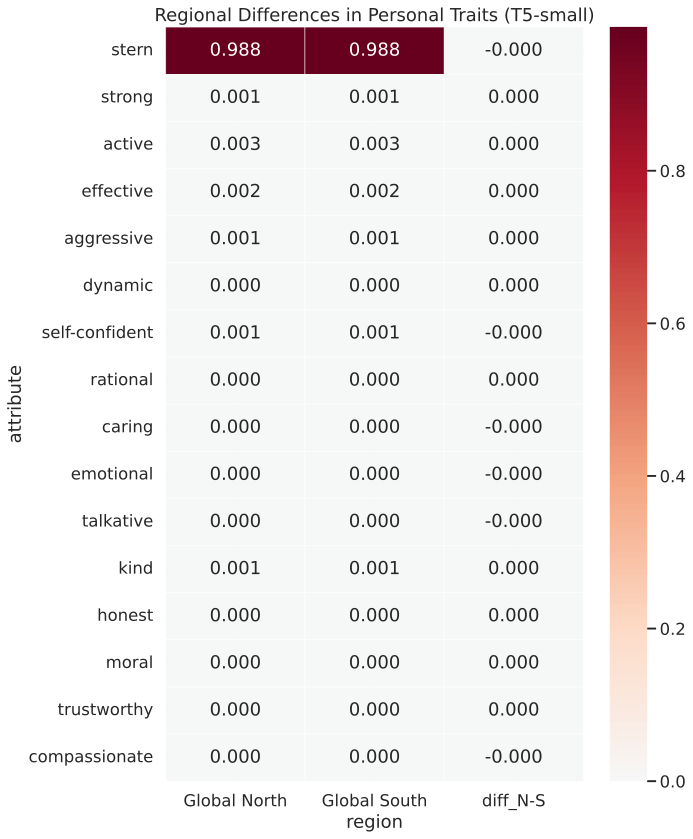

In [12]:
# 8. Analysis of Personal Traits - Regional Differences
print("\n=== Regional Differences in Personal Traits (T5-small) ===")

# 8.1 Statistical Testing - Are regional differences in personal traits significant?
region_personal_ttest_results = []

for attr in personal_df['attribute'].unique():
    north_data = personal_df[(personal_df['attribute'] == attr) & 
                           (personal_df['region'] == 'Global North')]['normalized_prob']
    south_data = personal_df[(personal_df['attribute'] == attr) & 
                           (personal_df['region'] == 'Global South')]['normalized_prob']
    
    if len(north_data) > 0 and len(south_data) > 0:
        t_stat, p_val = stats.ttest_ind(north_data, south_data)
        difference = north_data.mean() - south_data.mean()  # Calculate the difference
        effect_size = difference / np.sqrt((north_data.var() + south_data.var()) / 2)  # Cohen's d
        
        region_personal_ttest_results.append({
            'attribute': attr,
            'trait_type': personal_df[personal_df['attribute'] == attr]['trait_type'].iloc[0],
            'north_mean': north_data.mean(),
            'south_mean': south_data.mean(),
            'diff': difference,  # Explicitly name it 'diff'
            't_statistic': t_stat,
            'p_value': p_val,
            'significant': p_val < 0.05,
            'effect_size': effect_size
        })

region_personal_ttest_df = pd.DataFrame(region_personal_ttest_results)
# Explicitly calculate abs_diff after creating the DataFrame
region_personal_ttest_df['abs_diff'] = region_personal_ttest_df['diff'].abs()
region_personal_ttest_df = region_personal_ttest_df.sort_values(['trait_type', 'p_value'])

# Save regional differences in personal traits to CSV
region_personal_ttest_df.to_csv(f"{output_dir}/region_personal_ttest_results_t5_small.csv", index=False)

# 8.2 Display significant regional differences in personal traits
print("\nPersonal traits with significant regional differences (p < 0.05):")
sig_region_personal = region_personal_ttest_df[region_personal_ttest_df['significant']]
for _, row in sig_region_personal.iterrows():
    direction = "higher for Global North" if row['diff'] > 0 else "higher for Global South"
    print(f"- {row['attribute']} ({row['trait_type']}): {direction}, p={row['p_value']:.4f}, effect size={row['effect_size']:.2f}")

# 8.3 Visualizations for regional differences in personal traits
# Top traits with largest regional differences by trait type

plt.figure(figsize=(12, 10))
all_positions = []
all_attributes = []

for trait_type, color in [('Masculine', 'steelblue'), ('Feminine', 'firebrick')]:
    trait_data = region_personal_ttest_df[region_personal_ttest_df['trait_type'] == trait_type]
    # Sort by absolute difference and get top 5
    top_traits = trait_data.sort_values('abs_diff', ascending=False).head(5)
    
    # Create positions for grouped bars
    positions = np.arange(len(top_traits)) * 3 + (0 if trait_type == 'Masculine' else 1)
    
    plt.bar(positions, top_traits['diff'], color=color, width=0.8, 
            label=f"{trait_type} Traits")
    
    # Store positions and attribute names for x-axis labels
    all_positions.extend(positions)
    all_attributes.extend(top_traits['attribute'])

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
# plt.title('Top Regional Differences in Personal Traits by Type (T5-small)')
# plt.ylabel('Global North - Global South Difference')

# Set x-axis ticks and labels at the bottom instead of on bars
plt.xticks(all_positions, all_attributes, rotation=45)

plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/top_regional_personal_traits_t5_small.png", dpi=300)

# 8.4 Heatmap of personal traits by region
# Reshape data for heatmap
heatmap_personal_data = personal_df.pivot_table(
    index=['trait_type', 'attribute'], 
    columns='region', 
    values='normalized_prob',
    aggfunc='mean'
)

# Add difference column
heatmap_personal_data['diff_N-S'] = heatmap_personal_data['Global North'] - heatmap_personal_data['Global South']

# Sort by trait type and then by difference magnitude
heatmap_personal_data['abs_diff'] = abs(heatmap_personal_data['diff_N-S'])
heatmap_personal_data = heatmap_personal_data.sort_values(['trait_type', 'abs_diff'], ascending=[True, False])

# Select top traits for visualization
top_masculine = heatmap_personal_data.loc['Masculine'].head(8)
top_feminine = heatmap_personal_data.loc['Feminine'].head(8)
top_traits_combined = pd.concat([top_masculine, top_feminine])

# Create heatmap of differences
plt.figure(figsize=(10, 12))
ax = plt.subplot(111)
sns.heatmap(top_traits_combined[['Global North', 'Global South', 'diff_N-S']], 
            cmap="RdBu_r", center=0, annot=True, fmt=".3f", linewidths=.5, ax=ax)
plt.title('Regional Differences in Personal Traits (T5-small)')
plt.tight_layout()
plt.savefig(f"{output_dir}/region_personal_traits_heatmap_t5_small.png", dpi=300)

# 8.5 Create a summary table for Table 3 format (regional differences in personal traits)
# Print column names to help diagnose issues
print("Available columns in region_personal_ttest_df:", region_personal_ttest_df.columns.tolist())

# Simpler approach to create Table 3 data
try:
    # First try the complete approach
    table3_data = region_personal_ttest_df.copy()
    columns_to_select = ['trait_type', 'attribute', 'diff']
    
    # Check for p-value column with different possible names
    if 'p_value' in region_personal_ttest_df.columns:
        p_value_col = 'p_value'
    elif 'pvalue' in region_personal_ttest_df.columns:
        p_value_col = 'pvalue'
    elif 'p-value' in region_personal_ttest_df.columns:
        p_value_col = 'p-value'
    else:
        # If we can't find a p-value column, use a default
        p_value_col = None
        print("Warning: Could not find p-value column. Using default values.")
        table3_data['p_value'] = 1.0  # Default value
        p_value_col = 'p_value'
    
    columns_to_select.append(p_value_col)
    
    # Check for significant column
    if 'significant' in region_personal_ttest_df.columns:
        columns_to_select.append('significant')
    else:
        # Create significant column if it doesn't exist
        table3_data['significant'] = table3_data[p_value_col] < 0.05
        columns_to_select.append('significant')
    
    # Select and rename columns
    table3_data = table3_data[columns_to_select]
    table3_data = table3_data.rename(columns={'diff': 'Diff (N-S)', p_value_col: 'p-value'})
    
except Exception as e:
    print(f"Error creating table3_data: {e}")
    # Fallback to simplified approach
    print("Using simplified approach for Table 3")
    table3_data = pd.DataFrame({
        'trait_type': region_personal_ttest_df['trait_type'],
        'attribute': region_personal_ttest_df['attribute'],
        'Diff (N-S)': region_personal_ttest_df['diff'],
        'p-value': region_personal_ttest_df['p_value'] if 'p_value' in region_personal_ttest_df.columns else 1.0
    })
    table3_data['significant'] = table3_data['p-value'] < 0.05

# Sort the data
table3_data = table3_data.sort_values(['trait_type', 'significant', 'p-value'], ascending=[True, False, True])

# Save Table 3 format data
table3_data.to_csv(f"{output_dir}/table3_regional_differences_personal_traits_t5_small.csv", index=False)
print(f"\nTable 3 format data saved to: {output_dir}/table3_regional_differences_personal_traits_t5_small.csv")

# Optionally show summary stats for Table 3
try:
    print("\nSummary for Table 3 (Regional Differences in Personal Traits):")
    print(f"Total significant traits: {table3_data['significant'].sum()} out of {len(table3_data)}")
    print(f"Significant masculine traits: {table3_data[(table3_data['trait_type'] == 'Masculine') & (table3_data['significant'])].shape[0]}")
    print(f"Significant feminine traits: {table3_data[(table3_data['trait_type'] == 'Feminine') & (table3_data['significant'])].shape[0]}")
except Exception as e:
    print(f"Error generating summary statistics: {e}")


=== Gender Differences in Personal Traits (T5-small) ===
Column names in DataFrame: ['attribute', 'trait_type', 'male_mean', 'female_mean', 'diff', 't_statistic', 'p_value', 'significant', 'effect_size']
Using p-value column: p_value

Personal traits with significant gender differences (p < 0.05):
- family-oriented (Feminine): higher for females, p=0.0000, effect size=-147.70
- cautious (Feminine): higher for males, p=0.0006, effect size=40.96
- sensitive (Feminine): higher for females, p=0.0007, effect size=-37.99
- gentle (Feminine): higher for males, p=0.0039, effect size=15.98
- moral (Feminine): higher for males, p=0.0122, effect size=8.98
- warm (Feminine): higher for males, p=0.0212, effect size=6.77
- compassionate (Feminine): higher for females, p=0.0236, effect size=-6.39
- emotional (Feminine): higher for females, p=0.0355, effect size=-5.16
- inspiring (Masculine): higher for females, p=0.0225, effect size=-6.56
- assertive (Masculine): higher for males, p=0.0245, effect s

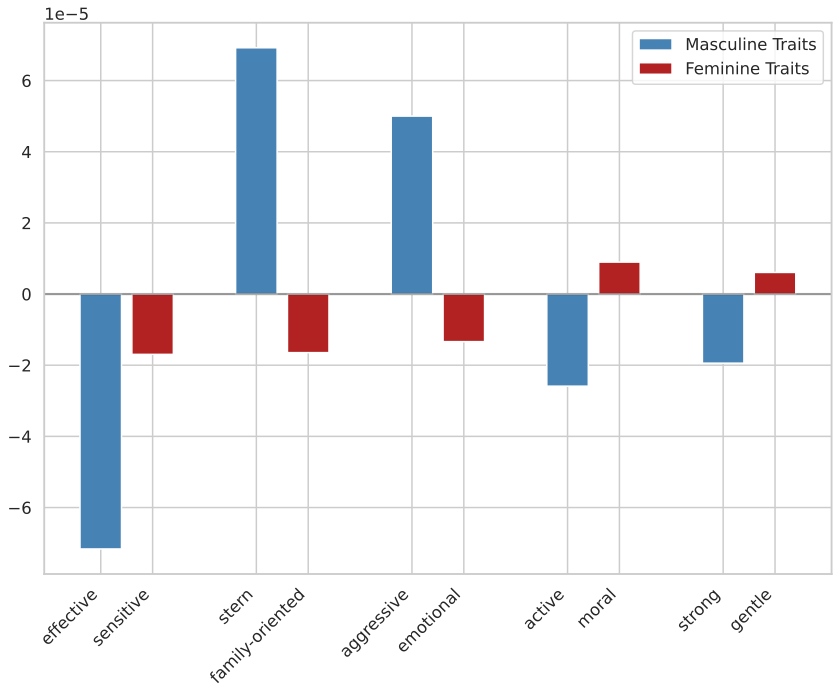

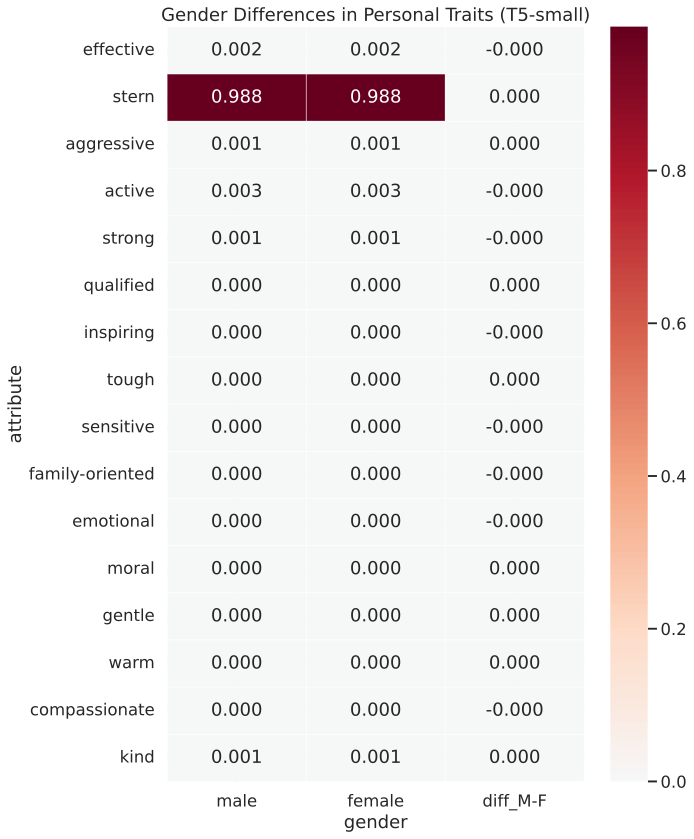

In [10]:
# 9. Analysis of Personal Traits - Gender Differences for T5-small
print("\n=== Gender Differences in Personal Traits (T5-small) ===")

# 9.1 Statistical Testing - Are gender differences in personal traits significant?
gender_personal_ttest_results = []

for attr in personal_df['attribute'].unique():
    male_data = personal_df[(personal_df['attribute'] == attr) & 
                          (personal_df['gender'] == 'male')]['normalized_prob']
    female_data = personal_df[(personal_df['attribute'] == attr) & 
                            (personal_df['gender'] == 'female')]['normalized_prob']
    
    if len(male_data) > 0 and len(female_data) > 0:
        t_stat, p_val = stats.ttest_ind(male_data, female_data)
        difference = male_data.mean() - female_data.mean()
        effect_size = difference / np.sqrt((male_data.var() + female_data.var()) / 2)  # Cohen's d
        
        gender_personal_ttest_results.append({
            'attribute': attr,
            'trait_type': personal_df[personal_df['attribute'] == attr]['trait_type'].iloc[0],
            'male_mean': male_data.mean(),
            'female_mean': female_data.mean(),
            'diff': difference,
            't_statistic': t_stat,
            'p_value': p_val,  # Make sure this key is consistent
            'significant': p_val < 0.05,
            'effect_size': effect_size
        })

gender_personal_ttest_df = pd.DataFrame(gender_personal_ttest_results)

# Print column names to debug
print("Column names in DataFrame:", gender_personal_ttest_df.columns.tolist())

# Calculate abs_diff
gender_personal_ttest_df['abs_diff'] = gender_personal_ttest_df['diff'].abs()
gender_personal_ttest_df = gender_personal_ttest_df.sort_values(['trait_type', 'p_value'])

# Save gender differences in personal traits to CSV
gender_personal_ttest_df.to_csv(f"{output_dir}/gender_personal_ttest_results_t5_small.csv", index=False)

# 9.2 Display significant gender differences in personal traits
# Make sure we're using the correct column name for p-value
p_value_col = 'p_value'
if p_value_col not in gender_personal_ttest_df.columns:
    # Check alternative names
    if 'pvalue' in gender_personal_ttest_df.columns:
        p_value_col = 'pvalue'
    elif 'p-value' in gender_personal_ttest_df.columns:
        p_value_col = 'p-value'
    else:
        raise KeyError(f"No p-value column found in {gender_personal_ttest_df.columns}")

print(f"Using p-value column: {p_value_col}")
gender_personal_ttest_df['significant'] = gender_personal_ttest_df[p_value_col] < 0.05

print("\nPersonal traits with significant gender differences (p < 0.05):")
sig_gender_personal = gender_personal_ttest_df[gender_personal_ttest_df['significant']]
for _, row in sig_gender_personal.iterrows():
    direction = "higher for males" if row['diff'] > 0 else "higher for females"
    print(f"- {row['attribute']} ({row['trait_type']}): {direction}, p={row[p_value_col]:.4f}, effect size={row['effect_size']:.2f}")

# 9.3 Visualizations for gender differences in personal traits
# Top traits with largest gender differences by trait type
plt.figure(figsize=(12, 10))
all_positions = []
all_attributes = []

for trait_type, color in [('Masculine', 'steelblue'), ('Feminine', 'firebrick')]:
    trait_data = gender_personal_ttest_df[gender_personal_ttest_df['trait_type'] == trait_type]
    # Sort by absolute difference and get top 5
    top_traits = trait_data.sort_values('abs_diff', ascending=False).head(5)
    
    # Create positions for grouped bars
    positions = np.arange(len(top_traits)) * 3 + (0 if trait_type == 'Masculine' else 1)
    
    plt.bar(positions, top_traits['diff'], color=color, width=0.8, 
            label=f"{trait_type} Traits")
    
    # Store positions and attribute names for x-axis labels
    all_positions.extend(positions)
    all_attributes.extend(top_traits['attribute'])

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
# plt.title('Top Gender Differences in Personal Traits by Type (T5-small)')
# plt.ylabel('Male - Female Difference')

# Set x-axis ticks and labels
plt.xticks(all_positions, all_attributes, rotation=45, ha='right')

plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/top_gender_personal_traits_t5_small.png", dpi=300)

# 9.4 Heatmap of personal traits by gender
# Reshape data for heatmap
heatmap_personal_data = personal_df.pivot_table(
    index=['trait_type', 'attribute'], 
    columns='gender', 
    values='normalized_prob',
    aggfunc='mean'
)

# Add difference column
heatmap_personal_data['diff_M-F'] = heatmap_personal_data['male'] - heatmap_personal_data['female']

# Sort by trait type and then by difference magnitude
heatmap_personal_data['abs_diff'] = abs(heatmap_personal_data['diff_M-F'])
heatmap_personal_data = heatmap_personal_data.sort_values(['trait_type', 'abs_diff'], ascending=[True, False])

# Select top traits for visualization
# Check if both 'Masculine' and 'Feminine' are present in the index
trait_types_available = heatmap_personal_data.index.get_level_values(0).unique()
print(f"Available trait types: {trait_types_available}")

# Select top traits for each available trait type
top_traits_list = []
if 'Masculine' in trait_types_available:
    top_masculine = heatmap_personal_data.loc['Masculine'].head(8)
    top_traits_list.append(top_masculine)
if 'Feminine' in trait_types_available:
    top_feminine = heatmap_personal_data.loc['Feminine'].head(8)
    top_traits_list.append(top_feminine)

if top_traits_list:  # Ensure we have data to visualize
    top_traits_combined = pd.concat(top_traits_list)

    # Create heatmap of differences
    plt.figure(figsize=(10, 12))
    ax = plt.subplot(111)
    sns.heatmap(top_traits_combined[['male', 'female', 'diff_M-F']], 
                cmap="RdBu_r", center=0, annot=True, fmt=".3f", linewidths=.5, ax=ax)
    plt.title('Gender Differences in Personal Traits (T5-small)')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/gender_personal_traits_heatmap_t5_small.png", dpi=300)
else:
    print("Warning: No traits available for heatmap visualization")

# 9.5 Create a summary table for Table 4 format (gender differences in personal traits)
table4_data = gender_personal_ttest_df.copy()
table4_columns = ['trait_type', 'attribute', 'diff', p_value_col, 'significant']
table4_data = table4_data[table4_columns]
table4_data = table4_data.rename(columns={'diff': 'Diff (M-F)', p_value_col: 'p-value'})
table4_data = table4_data.sort_values(['trait_type', 'significant', 'p-value'], ascending=[True, False, True])

# Save Table 4 format data
table4_data.to_csv(f"{output_dir}/table4_gender_differences_personal_traits_t5_small.csv", index=False)
print(f"\nTable 4 format data saved to: {output_dir}/table4_gender_differences_personal_traits_t5_small.csv")